In [ ]:
import sys
sys.path.append(r"C://Users/ech77/OneDrive - University of Cambridge/PhD work/Code/hBN_PL/src")

from pathlib import Path
import numpy as np

import hbn_pl.io as io
import hbn_pl.preprocess as preprocess
import hbn_pl.plot as plot
import hbn_pl.peaks as peaks

In [251]:
DATA_DIR = Path("C://Users/ech77/OneDrive - University of Cambridge/PhD work/Data/2026/May/07.05.26/PyBTM PL")
FILE_NAME = '2026-05-07 15_23_21 PyBTM_500uW_10s_emitter 11.spe'
spe_path = DATA_DIR / FILE_NAME
wavelength, frames = io.load_spe(spe_path)

Performing background subtraction...
Successfully subtracted background.


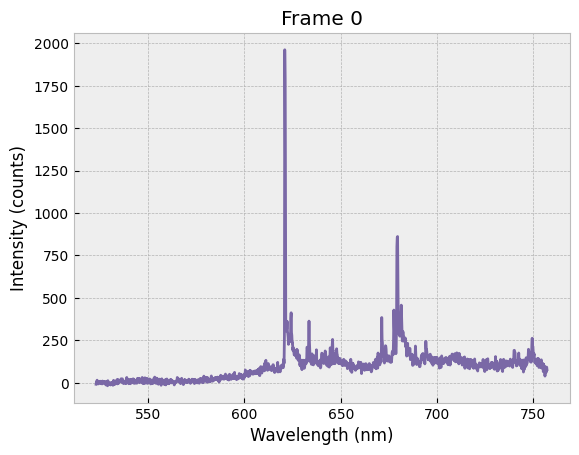

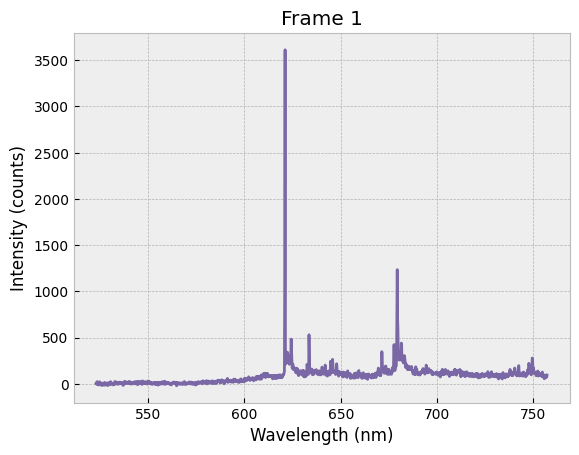

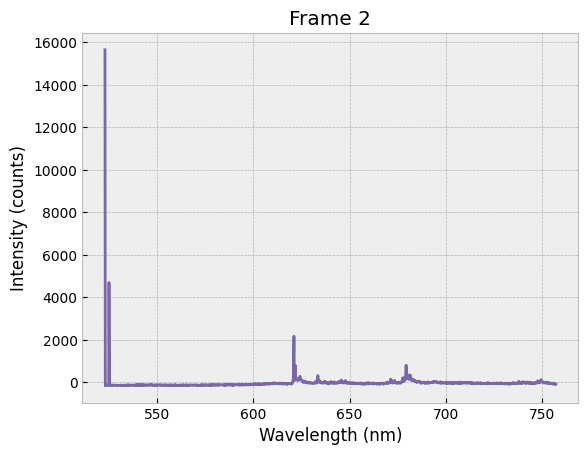

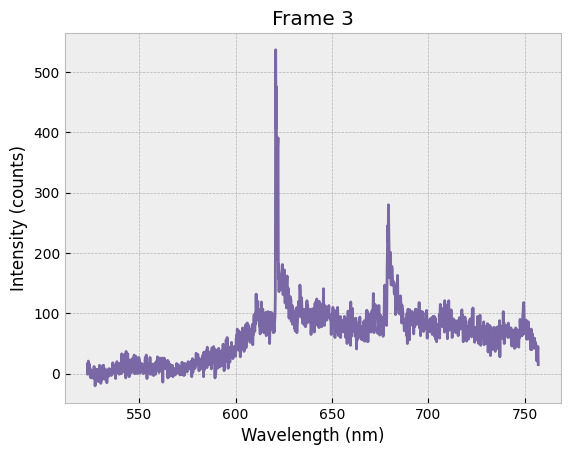

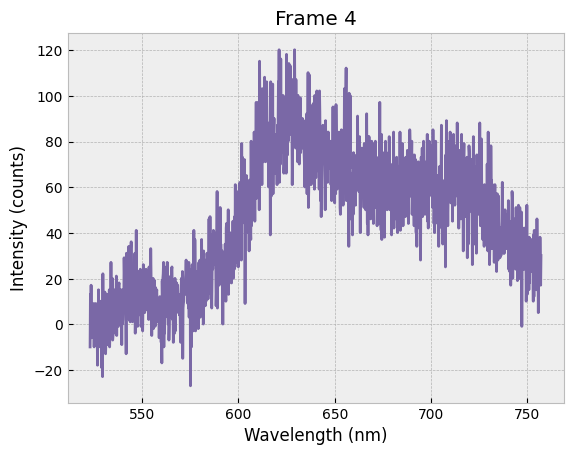

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

In [252]:
# Background subtraction
frames = preprocess.background_subtract(frames, bg_slice=(1, 50))
plot.plot_frames(frames, wavelength)

Detecting cosmic ray frames...
Detected 1 cosmic ray frames: [2]
Cosmic ray wavelengths: {2: [525.067167058789]}
Cosmic ray detection complete.


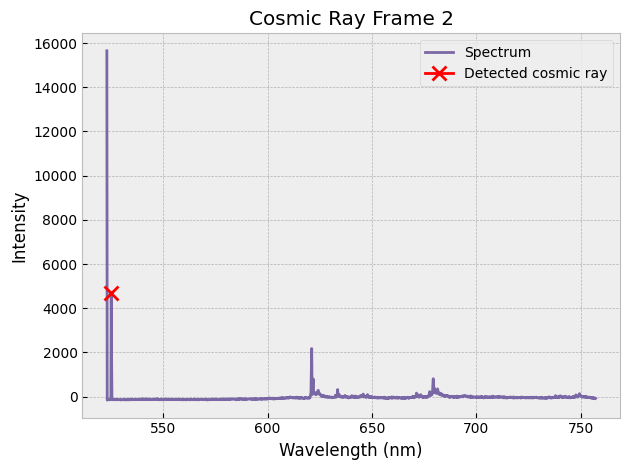

Removing cosmic rays from 1 frames: [2]


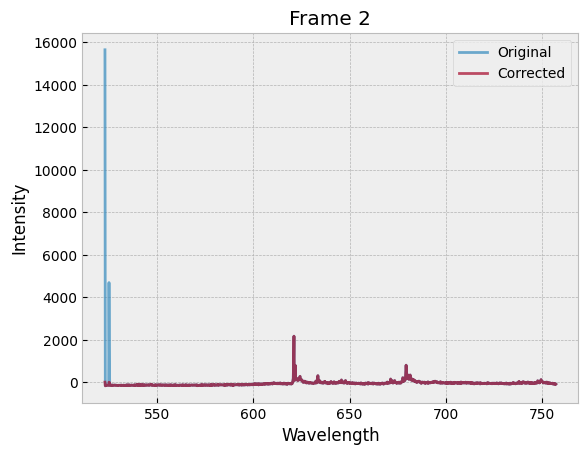

In [253]:
# Cosmic ray removal
cosmic_frames, cosmic_location = preprocess.detect_cosmic_frames(frames, wavelength,
prominence_threshold=0.05, fwhm_threshold=1.9, n_peaks=3, z_thresh=100, half_width=5, noise_width=30)
plot.plot_cosmic_frames(frames, wavelength, cosmic_location)
frames_cleaned, cosmic_figs = preprocess.remove_cosmic_rays(frames, wavelength, cosmic_frames, cosmic_location, sigma=1.5, half_width = 5)

In [ ]:
# Bad frame removal
drop_fraction = 0.6
bad_frames = preprocess.detect_bad_frames_simple(frames_cleaned, drop_fraction = drop_fraction)
#bad_frames = [0,3,4]
frames = preprocess.remove_frames(frames_cleaned, bad_frames)

Running simple bad frame detection...
Detected bad frames due to intensity drop 0.6: [2]
Removing 3 frames: [0, 3, 4]
Successfully removed bad frames.


In [245]:
#Line up ZPLs for many frames to fix spectral jumping
#aligned_frames, zpls, ref_zpl = preprocess.align_zpl(frames, wavelength)

Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


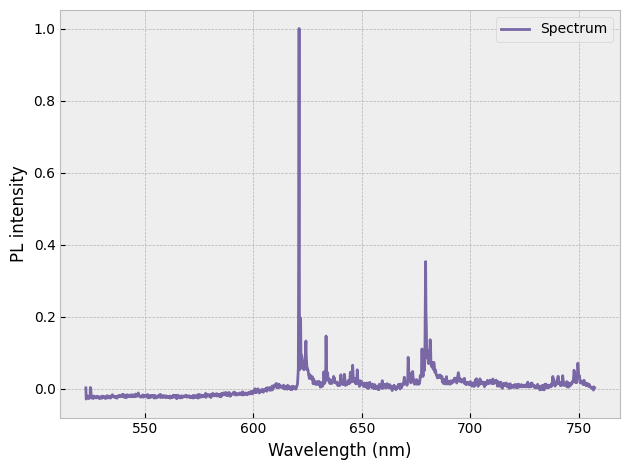

In [255]:
# Average frames and normalise
avg, avg_norm = preprocess.average_and_normalise(frames)
plot.plot_spectrum(x = wavelength, spectrum = avg_norm, x_quantity='Wavelength (nm)')

In [256]:
# Guess the ZPL wavelength by assuming it is the tallest peak in the spectrum
max_index = np.argmax(avg_norm)
zpl_wavelength = wavelength[max_index]
print("Estimated ZPL:", zpl_wavelength)

Estimated ZPL: 621.1105095318737


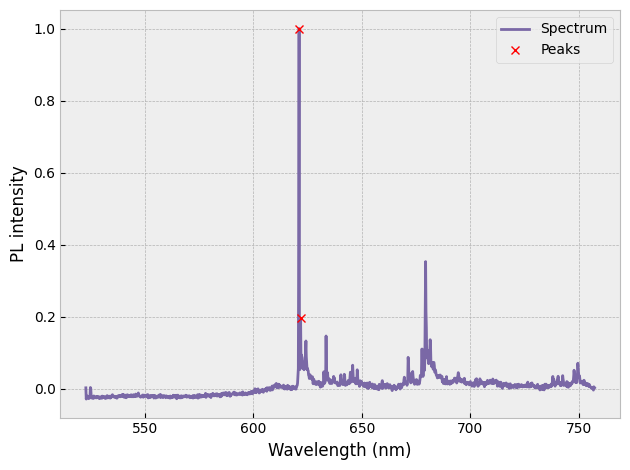

[{'location': np.float64(621.1105095318737), 'intensity': np.float64(1.0), 'fwhm': np.float64(0.17491299691505446), 'prominence': np.float64(0.9712172386317964)}, {'location': np.float64(621.8101597582889), 'intensity': np.float64(0.1963531493925441), 'fwhm': np.float64(0.3498247602083211), 'prominence': np.float64(0.14286671226405115)}]
Found ZPL-like peaks at wavelengths: [621.11050953 621.81015976]


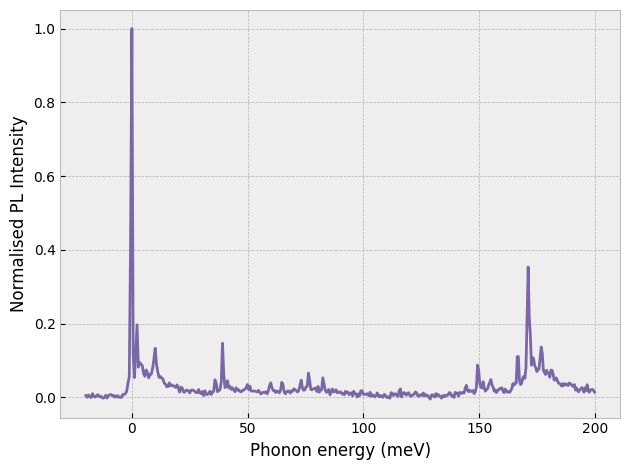

In [257]:
# Find ZPLs centred around the guessed ZPL wavelength
peaks_found, properties = peaks.find_peaks(avg_norm, x=wavelength, center_guess=zpl_wavelength, window=5, height=0.1, width = 0.5, prominence = 0.1)
peak_params = peaks.extract_peak_parameters(wavelength, avg_norm, peaks_found, properties)
plot.plot_spectrum(x = wavelength, spectrum = avg_norm, peaks=peaks_found, x_quantity='Wavelength (nm)')
plot.plot_energy(wavelength, avg_norm, zpl_wavelength=zpl_wavelength)
print(peak_params)
print("Found ZPL-like peaks at wavelengths:", wavelength[peaks_found])

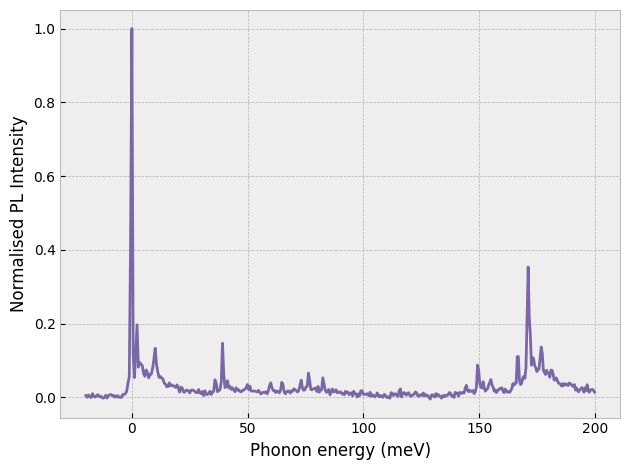

In [258]:
intensity, energy, figure = plot.plot_energy(wavelength, avg_norm, zpl_wavelength)

In [259]:
io.save_preprocess_results(spe_path, intensity, energy, figure, zpl_wavelength)

Saved: C:\Users\ech77\OneDrive - University of Cambridge\PhD work\Data\2026\May\07.05.26\PyBTM PL\2026-05-07 15_23_21 PyBTM_500uW_10s_emitter 11_cleaned.npz
Saved: C:\Users\ech77\OneDrive - University of Cambridge\PhD work\Data\2026\May\07.05.26\PyBTM PL\2026-05-07 15_23_21 PyBTM_500uW_10s_emitter 11_cleaned.png
Updated: C:\Users\ech77\OneDrive - University of Cambridge\PhD work\Data\2026\May\07.05.26\PyBTM PL\ZPL_wavelengths.csv
